# Joint Model for Longitudinal and Discrete Survival Data

This notebook implements the **joint model** from Medina-Olivares et al. (2022),
extended to **competing risks** (prepayment and default).

The model jointly estimates:
1. **Longitudinal submodel**: AR(1) + random intercept + random slope for the
   prepayment incentive (`ppi_c_FRMA`), an endogenous time-varying covariate.
2. **Survival submodel**: discrete-time multinomial logit (current / prepay / default)
   linked to the longitudinal submodel through the model-implied TVC trajectory.

**Reference**: Medina-Olivares, V., Calabrese, R., Crook, J. & Lindgren, F. (2022).
"Joint models for longitudinal and discrete survival data in credit scoring."
*EJOR*, 307(3), 1457-1473.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import pyro
import arviz as az

from src.competing_risks.joint_model import (
    JointCompetingRisksModel,
    prepare_joint_model_data,
    STATIC_FEATURES,
    TVC_DEFAULT,
)
from src.competing_risks.evaluation import (
    time_dependent_concordance_index,
    brier_score_competing_risks,
    evaluate_all_events,
    EVAL_TIMES,
)

print(f'PyTorch: {torch.__version__}')
print(f'Pyro:    {pyro.__version__}')
print(f'Device:  cpu (float64 required for NUTS stability)')

PyTorch: 2.3.1
Pyro:    1.9.1
Device:  cpu (float64 required for NUTS stability)


In [3]:
# === CONFIGURATION ===
DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
MODELS_DIR = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Feature sets
STATIC_COLS = ['int_rate', 'log_upb', 'fico_score', 'dti_r', 'ltv_r']
TVC_COL = 'ppi_c_FRMA'

# Fold assignments (matching other notebooks)
TRAIN_FOLDS = list(range(9))
VAL_FOLDS = [9]
TEST_FOLD = 10

# MCMC settings (conservative for development; increase for production)
NUM_WARMUP = 500
NUM_SAMPLES = 1000
NUM_CHAINS = 4  # increase to 4 for production runs

# Subsample (e.g. 2000) for development (set to None for full dataset)
MAX_LOANS = None  # start small, scale up once validated

SEED = 42

---

## 1. Load and Prepare Data

In [4]:
# Load the loan-month panel
print("Loading loan-month panel data...")
panel = pd.read_parquet(DATA_DIR / 'loan_month_panel.parquet')
print(f'Full panel: {panel.shape[0]:,} rows, {panel["loan_sequence_number"].nunique():,} loans')

# Create log_upb if needed
if 'log_upb' not in panel.columns and 'orig_upb' in panel.columns:
    panel['log_upb'] = np.log(panel['orig_upb'].clip(lower=1).astype(float))

# Create bal_repaid_lag1 if needed (not used in joint model, but for completeness)
if 'bal_repaid_lag1' not in panel.columns and 'bal_repaid' in panel.columns:
    panel['bal_repaid_lag1'] = panel.groupby('loan_sequence_number')['bal_repaid'].shift(1)
    panel['bal_repaid_lag1'] = panel['bal_repaid_lag1'].fillna(0)

# Drop rows with missing features
required_cols = STATIC_COLS + [TVC_COL]
panel = panel.dropna(subset=required_cols)
print(f'After dropna: {panel.shape[0]:,} rows, {panel["loan_sequence_number"].nunique():,} loans')

Loading loan-month panel data...
Full panel: 5,462,536 rows, 109,111 loans
After dropna: 5,462,536 rows, 109,111 loans


In [5]:
# Train / test split by fold
train_panel = panel[panel['fold'].isin(TRAIN_FOLDS)].copy()
test_panel = panel[panel['fold'] == TEST_FOLD].copy()

print(f'Train: {train_panel["loan_sequence_number"].nunique():,} loans, '
      f'{train_panel.shape[0]:,} rows')
print(f'Test:  {test_panel["loan_sequence_number"].nunique():,} loans, '
      f'{test_panel.shape[0]:,} rows')

# Subsample for development speed
if MAX_LOANS is not None:
    rng = np.random.RandomState(SEED)
    train_loan_ids = train_panel['loan_sequence_number'].unique()
    if len(train_loan_ids) > MAX_LOANS:
        # Stratified: keep proportional event mix
        loan_events = train_panel.groupby('loan_sequence_number')['event_code'].last()
        sampled_ids = []
        for evt in [0, 1, 2]:
            pool = loan_events[loan_events == evt].index.values
            n_take = max(1, int(MAX_LOANS * len(pool) / len(train_loan_ids)))
            sampled_ids.extend(rng.choice(pool, size=min(n_take, len(pool)), replace=False))
        sampled_ids = np.array(sampled_ids)[:MAX_LOANS]
        train_panel = train_panel[train_panel['loan_sequence_number'].isin(sampled_ids)]
        print(f'\nSubsampled train: {train_panel["loan_sequence_number"].nunique():,} loans, '
              f'{train_panel.shape[0]:,} rows')

    test_loan_ids = test_panel['loan_sequence_number'].unique()
    if len(test_loan_ids) > MAX_LOANS:
        sampled_test = rng.choice(test_loan_ids, size=MAX_LOANS, replace=False)
        test_panel = test_panel[test_panel['loan_sequence_number'].isin(sampled_test)]
        print(f'Subsampled test:  {test_panel["loan_sequence_number"].nunique():,} loans, '
              f'{test_panel.shape[0]:,} rows')

# Event distribution in train
print('\nTrain event distribution:')
print(train_panel.groupby('loan_sequence_number')['event_code'].last().value_counts().sort_index()
      .rename({0: 'Censored', 1: 'Prepay', 2: 'Default'}))

Train: 89,274 loans, 4,466,909 rows
Test:  9,918 loans, 495,858 rows

Train event distribution:
event_code
Censored    39003
Prepay      50237
Default        34
Name: count, dtype: int64


---

## 2. Explore the TVC: Prepayment Incentive (ppi_c_FRMA)

Before fitting the joint model, let's examine the time-varying covariate we're modelling longitudinally.

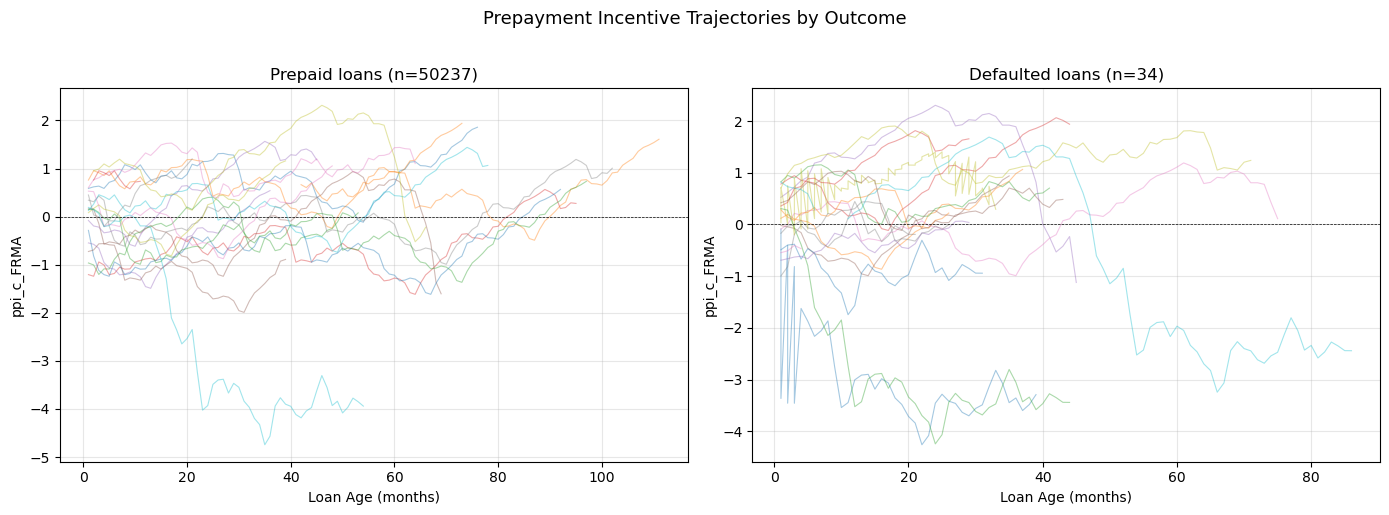


ppi_c_FRMA summary:
count    4.466909e+06
mean    -4.517000e-01
std      1.548800e+00
min     -5.995000e+00
25%     -1.116000e+00
50%     -6.800000e-02
75%      6.260000e-01
max      3.941000e+00
Name: ppi_c_FRMA, dtype: float64


In [6]:
# Plot TVC trajectories for a sample of loans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample loans by outcome
loan_last = train_panel.groupby('loan_sequence_number').last()
rng_plot = np.random.RandomState(42)

for ax, (evt, label) in zip(axes, [(1, 'Prepaid'), (2, 'Defaulted')]):
    pool = loan_last[loan_last['event_code'] == evt].index.values
    sample = rng_plot.choice(pool, size=min(20, len(pool)), replace=False)
    for lid in sample:
        loan_data = train_panel[train_panel['loan_sequence_number'] == lid]
        ax.plot(loan_data['loan_age'].values, loan_data[TVC_COL].values,
                alpha=0.4, linewidth=0.8)
    ax.set_xlabel('Loan Age (months)')
    ax.set_ylabel(TVC_COL)
    ax.set_title(f'{label} loans (n={len(pool)})')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prepayment Incentive Trajectories by Outcome', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Summary stats
print(f'\n{TVC_COL} summary:')
print(train_panel[TVC_COL].describe().round(4))

---

## 3. Prepare Data for Joint Model

Transform the loan-month panel into the tensors needed by the Pyro model.

In [7]:
# Prepare data structures
train_data = prepare_joint_model_data(
    train_panel,
    tvc_col=TVC_COL,
    static_cols=STATIC_COLS,
)

print(f"Longitudinal observations (N):  {train_data['N']:,}")
print(f"Loans (N_loans):                {train_data['N_loans']:,}")
print(f"Max loan age (T_max):           {train_data['T_max']}")
print(f"B-spline basis functions:       {train_data['n_basis']}")
print(f"Static covariates (P):          {train_data['P']}")
print(f"Static columns:                 {train_data['static_cols']}")
print(f"TVC column:                     {train_data['tvc_col']}")

# Event distribution
evt_counts = pd.Series(train_data['event_type']).value_counts().sort_index()
print(f"\nEvent distribution:")
for k, v in evt_counts.items():
    label = {0: 'Censored', 1: 'Prepay', 2: 'Default'}[k]
    print(f"  {label}: {v:,} ({v/len(train_data['event_type'])*100:.1f}%)")

Longitudinal observations (N):  4,466,909
Loans (N_loans):                89,274
Max loan age (T_max):           184
B-spline basis functions:       7
Static covariates (P):          5
Static columns:                 ['int_rate', 'log_upb', 'fico_score', 'dti_r', 'ltv_r']
TVC column:                     ppi_c_FRMA

Event distribution:
  Censored: 39,003 (43.7%)
  Prepay: 50,237 (56.3%)
  Default: 34 (0.0%)


---

## 4. Fit the Joint Model

Run Bayesian MCMC (NUTS) via Pyro. This is the most computationally intensive step.

In [8]:
%%time

model = JointCompetingRisksModel(
    tvc_col=TVC_COL,
    static_cols=STATIC_COLS,
    n_interior_knots=3,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    target_accept_prob=0.90,
    random_seed=SEED,
    device='cpu',
)

model.fit(train_panel)
print('\nMCMC complete.')

Warmup [1]:   0%|          | 0/1500 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/1500 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/1500 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/1500 [00:00, ?it/s]

[ERROR LOG CHAIN:2]Expected parameter log_factor (Tensor of shape ()) of distribution Unit(log_factor: nan) to satisfy the constraint Real(), but found invalid values:
nan
      Trace Shapes:            
       Param Sites:            
      Sample Sites:            
       alpha_0 dist |          
              value |          
           phi dist |          
              value |          
         sigma dist |          
              value |          
           tau dist |       2  
              value |       2  
       L_Omega dist |       2 2
              value |       2 2
          z_RE dist |   89274 2
              value |   89274 2
         Y_obs dist | 4466909  
              value | 4466909  
      a_prepay dist |       7  
              value |       7  
     a_default dist |       7  
              value |       7  
  gamma_prepay dist |       5  
              value |       5  
 gamma_default dist |       5  
              value |       5  
 lambda_prepay dist |       

ValueError: Expected parameter log_factor (Tensor of shape ()) of distribution Unit(log_factor: nan) to satisfy the constraint Real(), but found invalid values:
nan
      Trace Shapes:            
       Param Sites:            
      Sample Sites:            
       alpha_0 dist |          
              value |          
           phi dist |          
              value |          
         sigma dist |          
              value |          
           tau dist |       2  
              value |       2  
       L_Omega dist |       2 2
              value |       2 2
          z_RE dist |   89274 2
              value |   89274 2
         Y_obs dist | 4466909  
              value | 4466909  
      a_prepay dist |       7  
              value |       7  
     a_default dist |       7  
              value |       7  
  gamma_prepay dist |       5  
              value |       5  
 gamma_default dist |       5  
              value |       5  
 lambda_prepay dist |          
   

---

## 5. MCMC Diagnostics

Check convergence: R-hat, effective sample size, and trace plots.

In [9]:
# Posterior summary for key parameters
summary_df = model.get_posterior_summary()
print("Posterior Summary (key parameters):")
print(summary_df[~summary_df['parameter'].str.startswith('a_')].to_string(index=False))
print(f"\n{'─'*60}")
print("Baseline hazard coefficients:")
print(summary_df[summary_df['parameter'].str.startswith('a_')].to_string(index=False))

Posterior Summary (key parameters):
         parameter      mean      std        5%       95%
           alpha_0 -0.013323 0.001084 -0.015175 -0.011547
               phi  0.987772 0.001078  0.986044  0.989585
             sigma  0.212904 0.000467  0.212165  0.213667
     lambda_prepay  0.583542 0.033901  0.530873  0.640124
    lambda_default  0.598717 0.229145  0.215417  0.978426
     tau_intercept  0.078573 0.002569  0.074284  0.082917
         tau_slope  0.001520 0.000069  0.001406  0.001634
   prepay_int_rate -0.297458 0.057463 -0.390023 -0.205733
    prepay_log_upb  0.225985 0.033295  0.171039  0.281528
 prepay_fico_score -0.001456 0.031714 -0.053989  0.048541
      prepay_dti_r -0.128458 0.027662 -0.172766 -0.082683
      prepay_ltv_r -0.001079 0.031317 -0.053016  0.052255
  default_int_rate -0.022404 0.390564 -0.683032  0.580270
   default_log_upb  0.535967 0.297888  0.042776  1.045048
default_fico_score -0.024163 0.277320 -0.468095  0.422850
     default_dti_r -0.203196 0.23010

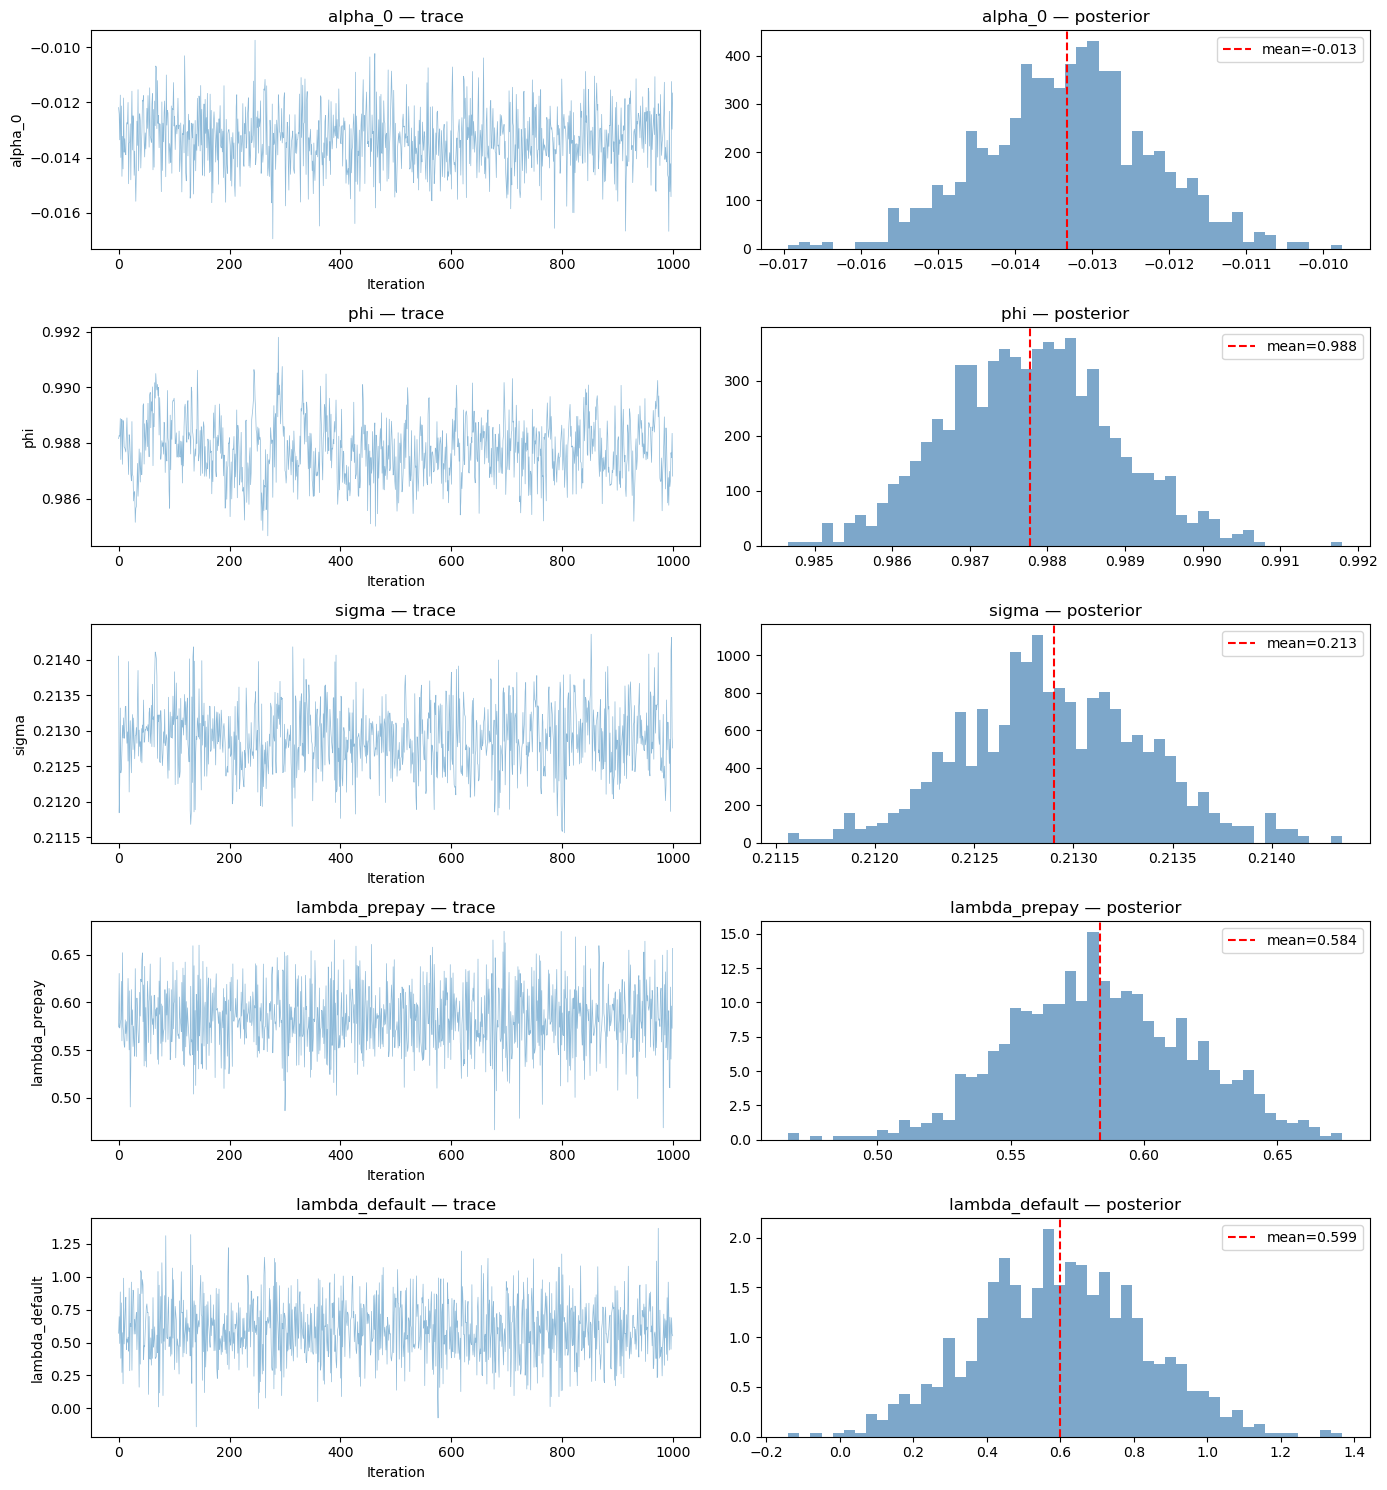

In [10]:
# Trace plots for key parameters
key_params = ['alpha_0', 'phi', 'sigma', 'lambda_prepay', 'lambda_default']

fig, axes = plt.subplots(len(key_params), 2, figsize=(14, 3 * len(key_params)))

for i, param in enumerate(key_params):
    samples = model.posterior_samples_[param]
    
    # Trace
    axes[i, 0].plot(samples, alpha=0.5, linewidth=0.5)
    axes[i, 0].set_ylabel(param)
    axes[i, 0].set_xlabel('Iteration')
    axes[i, 0].set_title(f'{param} — trace')
    
    # Density
    axes[i, 1].hist(samples, bins=50, density=True, alpha=0.7, color='steelblue')
    axes[i, 1].axvline(np.mean(samples), color='red', linestyle='--', label=f'mean={np.mean(samples):.3f}')
    axes[i, 1].set_title(f'{param} — posterior')
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'joint_model_traces.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Interpret Key Parameters

The **association parameters** ($\lambda_{\text{prepay}}$, $\lambda_{\text{default}}$) are the core result of the joint model — they quantify how the model-implied TVC trajectory links to each competing risk.

In [11]:
# Association parameters
print("=== Association Parameters ===\n")
print(f"ppi_c_FRMA = int_rate - current_30yr_FRM_average")
print(f"  Positive ppi_c_FRMA: loan rate > market rate (borrower locked into expensive loan)")
print(f"  Negative ppi_c_FRMA: loan rate < market rate (borrower has a good deal)\n")

for param in ['lambda_prepay', 'lambda_default']:
    samples = model.posterior_samples_[param]
    mean = np.mean(samples)
    ci_lo, ci_hi = np.percentile(samples, [2.5, 97.5])
    print(f"{param}:")
    print(f"  Mean: {mean:.4f}  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    if mean > 0:
        print(f"  -> Higher prepayment incentive INCREASES {param.split('_')[1]} risk")
    else:
        print(f"  -> Higher prepayment incentive DECREASES {param.split('_')[1]} risk")
    print()

# Longitudinal parameters
print("=== Longitudinal Parameters ===\n")
for param in ['alpha_0', 'phi', 'sigma']:
    samples = model.posterior_samples_[param]
    print(f"{param}: {np.mean(samples):.4f} (std={np.std(samples):.4f})")

print(f"\nphi = {np.mean(model.posterior_samples_['phi']):.4f}: "
      f"AR(1) coefficient — month-to-month persistence of prepayment incentive")

# Random effect SDs
if 'tau' in model.posterior_samples_:
    tau = model.posterior_samples_['tau']
    print(f"\ntau_intercept: {np.mean(tau[:, 0]):.4f} — cross-loan variation in TVC level")
    print(f"tau_slope:     {np.mean(tau[:, 1]):.4f} — cross-loan variation in TVC trend")

=== Association Parameters ===

ppi_c_FRMA = int_rate - current_30yr_FRM_average
  Positive ppi_c_FRMA: loan rate > market rate (borrower locked into expensive loan)
  Negative ppi_c_FRMA: loan rate < market rate (borrower has a good deal)

lambda_prepay:
  Mean: 0.5835  95% CI: [0.5192, 0.6492]
  -> Higher prepayment incentive INCREASES prepay risk

lambda_default:
  Mean: 0.5987  95% CI: [0.1478, 1.0394]
  -> Higher prepayment incentive INCREASES default risk

=== Longitudinal Parameters ===

alpha_0: -0.0133 (std=0.0011)
phi: 0.9878 (std=0.0011)
sigma: 0.2129 (std=0.0005)

phi = 0.9878: AR(1) coefficient — month-to-month persistence of prepayment incentive

tau_intercept: 0.0786 — cross-loan variation in TVC level
tau_slope:     0.0015 — cross-loan variation in TVC trend


---

## 7. Longitudinal Fit

Plot fitted vs observed TVC trajectories for a sample of loans to assess the longitudinal submodel.

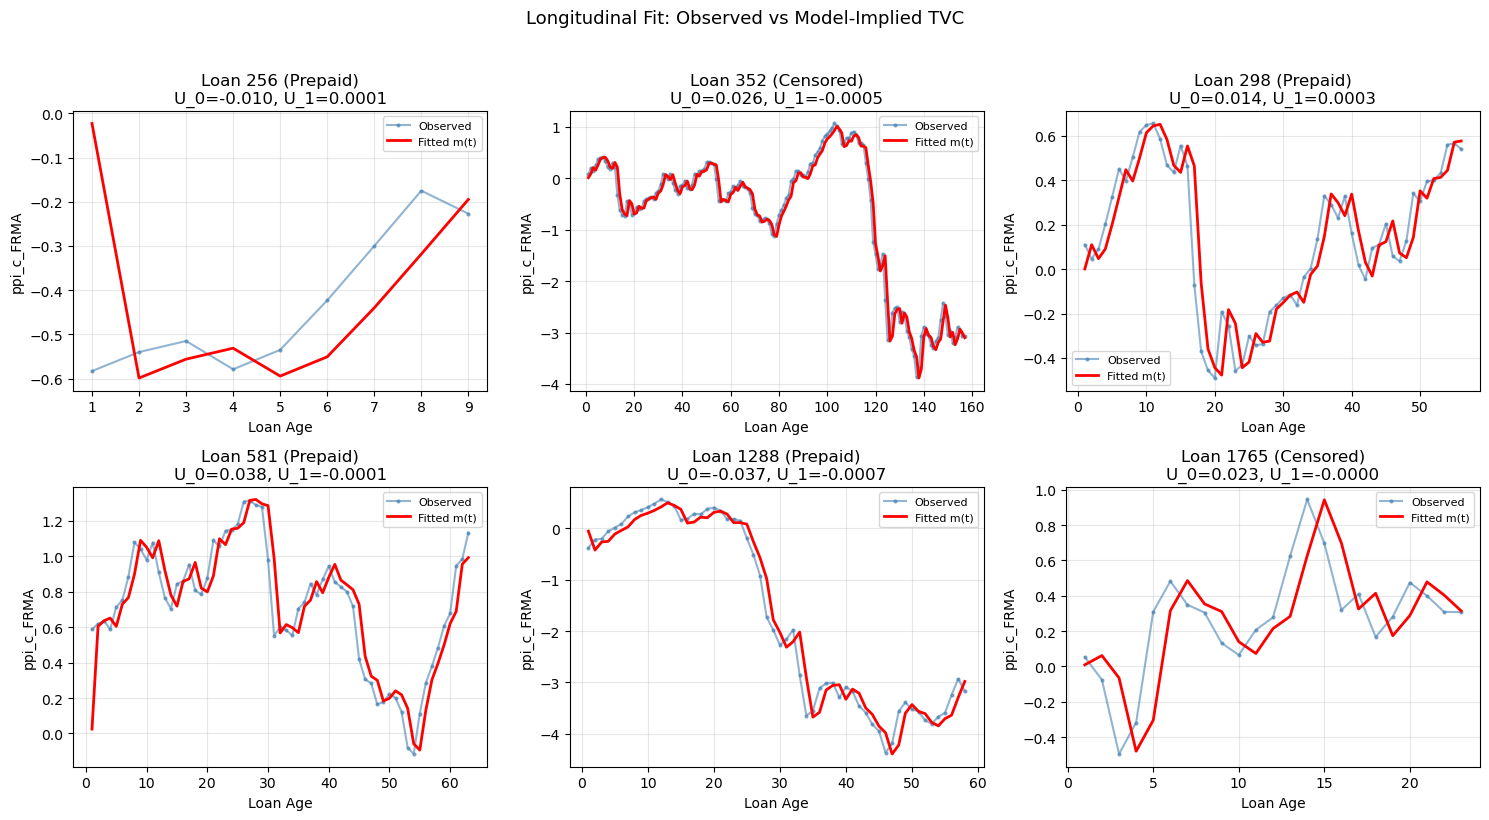

In [12]:
# Plot fitted longitudinal trajectories for sample loans
from src.competing_risks.joint_model import _estimate_random_effects

# Get posterior means
alpha_0_hat = np.mean(model.posterior_samples_['alpha_0'])
phi_hat = np.mean(model.posterior_samples_['phi'])
sigma_hat = np.mean(model.posterior_samples_['sigma'])

# Estimate random effects using posterior mean parameters
b_hat = _estimate_random_effects(
    model.data_, alpha_0_hat, phi_hat, sigma_hat,
    sample_idx=0, posterior_samples=model.posterior_samples_)

# Pick 6 loans with varying histories
train_data = model.data_
rng_plot = np.random.RandomState(42)
selected = rng_plot.choice(train_data['N_loans'], size=min(6, train_data['N_loans']), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax_idx, loan_idx in enumerate(selected):
    ax = axes[ax_idx]
    mask = train_data['obs_mask'][loan_idx]
    t_obs = np.where(mask)[0] + 1  # 1-indexed months
    y_obs = train_data['Y_by_loan'][loan_idx, mask]
    
    # Fitted trajectory: m_i(t) = alpha_0 + U_0i + U_1i*t + phi*Y_lag
    y_lag = train_data['Y_lag_by_loan'][loan_idx, mask]
    m_fitted = alpha_0_hat + b_hat[loan_idx, 0] + b_hat[loan_idx, 1] * t_obs + phi_hat * y_lag
    
    ax.plot(t_obs, y_obs, 'o-', markersize=2, alpha=0.6, label='Observed', color='steelblue')
    ax.plot(t_obs, m_fitted, '-', linewidth=2, label='Fitted m(t)', color='red')
    
    evt = train_data['event_type'][loan_idx]
    evt_label = {0: 'Censored', 1: 'Prepaid', 2: 'Defaulted'}[evt]
    ax.set_title(f'Loan {loan_idx} ({evt_label})\n'
                 f'U_0={b_hat[loan_idx,0]:.3f}, U_1={b_hat[loan_idx,1]:.4f}')
    ax.set_xlabel('Loan Age')
    ax.set_ylabel(TVC_COL)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Longitudinal Fit: Observed vs Model-Implied TVC', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'joint_model_longitudinal_fit.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. CIF Prediction on Test Set

Compute cumulative incidence functions at 24, 48, 72 months for the test loans.

In [13]:
%%time

# Compute CIF on test set
cif_result = model.predict_cif(
    test_panel,
    horizons=EVAL_TIMES,
    n_posterior_samples=min(200, NUM_SAMPLES),
)

print(f"Predicted CIF for {len(cif_result['loan_sequence_number']):,} test loans")
for t in EVAL_TIMES:
    cif_p = cif_result[f'cif_prepay_{t}']
    cif_d = cif_result[f'cif_default_{t}']
    print(f"  t={t}: CIF_prepay mean={cif_p.mean():.4f}, "
          f"CIF_default mean={cif_d.mean():.4f}, "
          f"CIF_total mean={(cif_p + cif_d).mean():.4f}")

Predicted CIF for 2,000 test loans
  t=24: CIF_prepay mean=0.2326, CIF_default mean=0.0028, CIF_total mean=0.2355
  t=48: CIF_prepay mean=0.4277, CIF_default mean=0.0065, CIF_total mean=0.4342
  t=72: CIF_prepay mean=0.6790, CIF_default mean=0.0623, CIF_total mean=0.7412
CPU times: user 16.4 s, sys: 1min 18s, total: 1min 34s
Wall time: 9.75 s


---

## 9. Evaluation: Time-Dependent C-index and Brier Score

In [14]:
# Time-dependent C-index
event_times = cif_result['duration']
event_codes = cif_result['event_code']

results_rows = []
for t in EVAL_TIMES:
    # Prepayment
    c_prepay, _, _ = time_dependent_concordance_index(
        event_times, event_codes,
        cif_result[f'cif_prepay_{t}'],
        eval_time=t, event_of_interest=1)
    
    # Default
    c_default, _, _ = time_dependent_concordance_index(
        event_times, event_codes,
        cif_result[f'cif_default_{t}'],
        eval_time=t, event_of_interest=2)
    
    # Brier scores
    bs_prepay = brier_score_competing_risks(
        event_times, event_codes,
        cif_result[f'cif_prepay_{t}'],
        eval_time=t, event_of_interest=1)
    
    bs_default = brier_score_competing_risks(
        event_times, event_codes,
        cif_result[f'cif_default_{t}'],
        eval_time=t, event_of_interest=2)
    
    results_rows.append({
        'Horizon': f't={t}',
        'C-index Prepay': c_prepay,
        'C-index Default': c_default,
        'Brier Prepay': bs_prepay,
        'Brier Default': bs_default,
    })

results_df = pd.DataFrame(results_rows)

# Add mean row
mean_row = {
    'Horizon': 'Mean',
    'C-index Prepay': results_df['C-index Prepay'].mean(),
    'C-index Default': results_df['C-index Default'].mean(),
    'Brier Prepay': results_df['Brier Prepay'].mean(),
    'Brier Default': results_df['Brier Default'].mean(),
}
results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

print("Joint Model (M5) — Evaluation Results")
print("=" * 70)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

Joint Model (M5) — Evaluation Results
Horizon  C-index Prepay  C-index Default  Brier Prepay  Brier Default
   t=24          0.7684           0.9971        0.1350         0.0005
   t=48          0.7755           1.0000        0.1713         0.0005
   t=72          0.7654           0.5605        0.2336         0.0064
   Mean          0.7698           0.8525        0.1800         0.0025


---

## 10. CIF Visualization

Plot predicted CIF distributions and compare prepayment vs default.

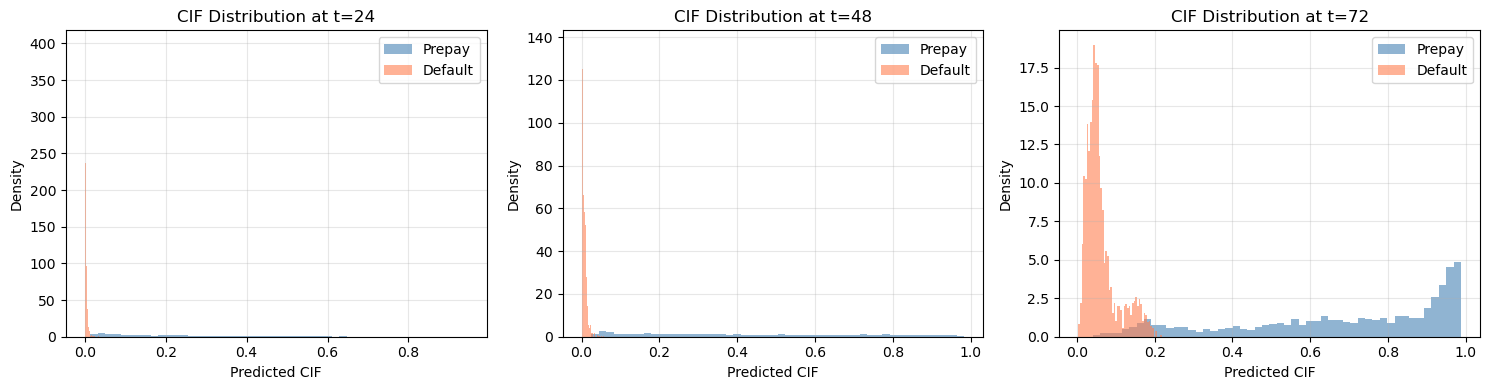

In [15]:
# CIF distributions at each horizon
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, t in zip(axes, EVAL_TIMES):
    ax.hist(cif_result[f'cif_prepay_{t}'], bins=50, alpha=0.6, 
            label='Prepay', color='steelblue', density=True)
    ax.hist(cif_result[f'cif_default_{t}'], bins=50, alpha=0.6, 
            label='Default', color='coral', density=True)
    ax.set_title(f'CIF Distribution at t={t}')
    ax.set_xlabel('Predicted CIF')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'joint_model_cif_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 11. Calibration

Compare predicted CIF against observed event rates.

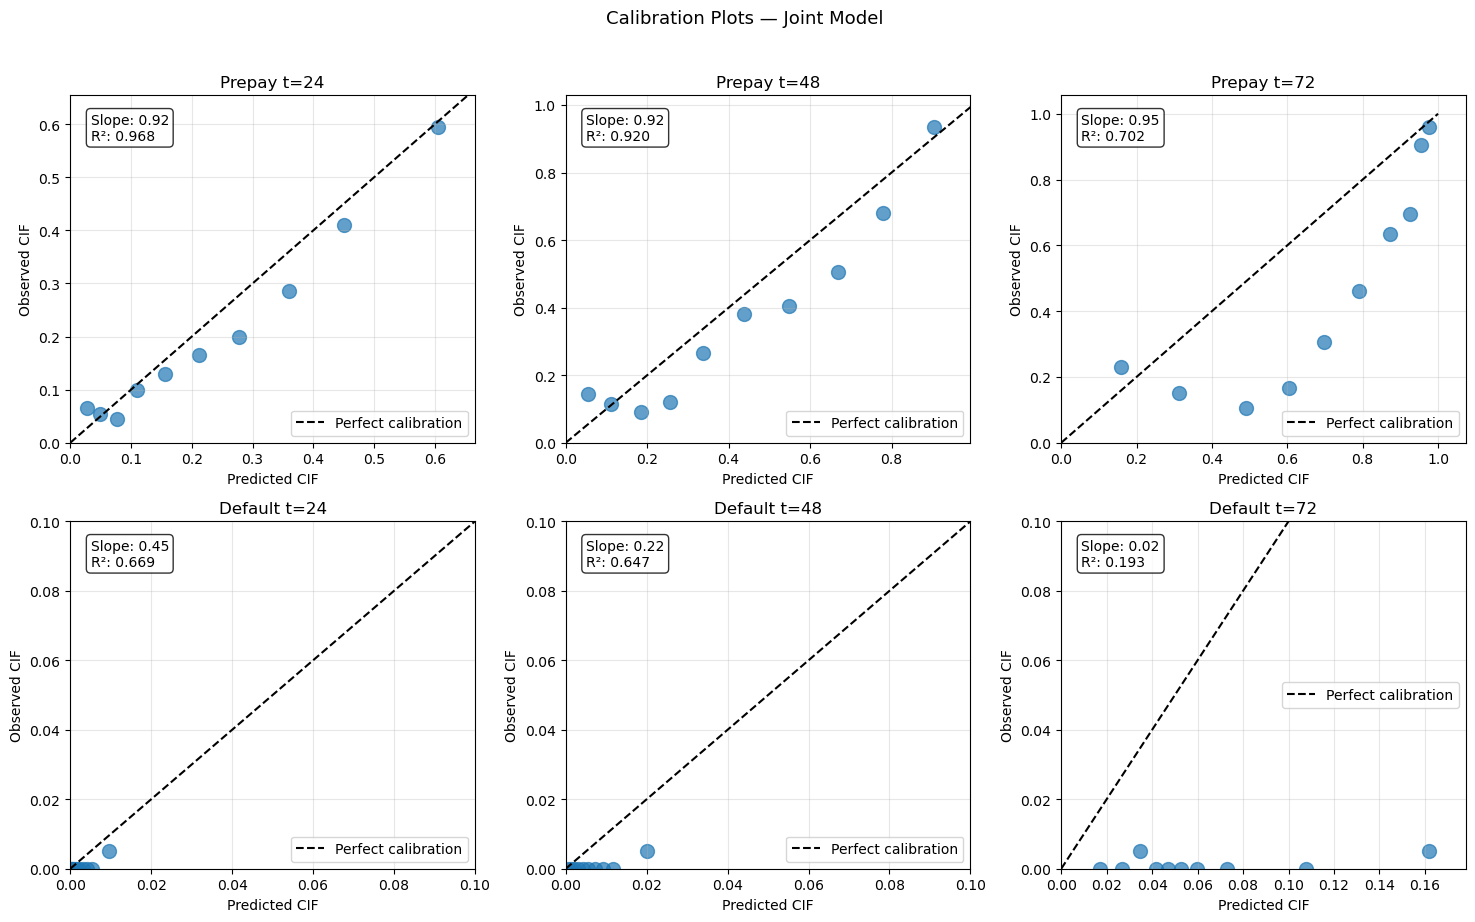

In [16]:
# Calibration plots
from src.competing_risks.evaluation import calibration_plot

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (event_code, event_name) in enumerate([(1, 'Prepay'), (2, 'Default')]):
    for row, t in enumerate(EVAL_TIMES):
        if row >= 3:
            break
        ax = axes[col, row]
        
        observed = ((event_times <= t) & (event_codes == event_code)).astype(float)
        predicted = cif_result[f'cif_{event_name.lower()}_{t}']
        
        calibration_plot(
            observed, predicted,
            n_bins=10, ax=ax,
            title=f'{event_name} t={t}'
        )

plt.suptitle('Calibration Plots — Joint Model', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'joint_model_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 12. Model Comparison

Compare joint model results with other models from previous notebooks.
Fill in results from notebooks 05-08 and 18 for a complete comparison table.

In [17]:
# Build comparison table
# Joint model results from this notebook
jm_results = {}
for t in EVAL_TIMES:
    c_p, _, _ = time_dependent_concordance_index(
        event_times, event_codes, cif_result[f'cif_prepay_{t}'], t, 1)
    c_d, _, _ = time_dependent_concordance_index(
        event_times, event_codes, cif_result[f'cif_default_{t}'], t, 2)
    jm_results[f'C_prepay_{t}'] = c_p
    jm_results[f'C_default_{t}'] = c_d

# Comparison table (fill in from other notebooks as available)
comparison = pd.DataFrame({
    'Metric': [f'C({t})' for t in EVAL_TIMES] + ['Mean C'],
    'Joint Model (Prepay)': [jm_results[f'C_prepay_{t}'] for t in EVAL_TIMES] + [
        np.mean([jm_results[f'C_prepay_{t}'] for t in EVAL_TIMES])],
    'Joint Model (Default)': [jm_results[f'C_default_{t}'] for t in EVAL_TIMES] + [
        np.mean([jm_results[f'C_default_{t}'] for t in EVAL_TIMES])],
})

print("Time-Dependent C-index: Joint Model")
print("=" * 60)
print(comparison.to_string(index=False, float_format='{:.4f}'.format))
print("\nNote: Add CSC, FGR, RSF, DeepHit, Sadhwani results from other notebooks for full comparison.")

Time-Dependent C-index: Joint Model
Metric  Joint Model (Prepay)  Joint Model (Default)
 C(24)                0.7684                 0.9971
 C(48)                0.7755                 1.0000
 C(72)                0.7654                 0.5605
Mean C                0.7698                 0.8525

Note: Add CSC, FGR, RSF, DeepHit, Sadhwani results from other notebooks for full comparison.


---

## 13. Summary

### Key Findings

| Parameter | Interpretation |
|-----------|---------------|
| `phi` (AR coefficient) | Persistence of prepayment incentive month-to-month |
| `lambda_prepay` | How the model-implied TVC trajectory affects prepayment hazard |
| `lambda_default` | How the model-implied TVC trajectory affects default hazard |
| `tau_intercept` | Cross-loan variation in TVC level |
| `tau_slope` | Cross-loan variation in TVC trend |

### Advantages Over Standard Models

1. **Handles TVC endogeneity** — the TVC trajectory and survival are modelled jointly, not conditionally
2. **Per-loan random effects** — captures heterogeneity in TVC dynamics across loans
3. **Integrated TVC projection** — future TVC values projected through the longitudinal submodel, with coefficients calibrated for projections (not observations)
4. **Full Bayesian uncertainty** — posterior distributions for all parameters and predictions

### Next Steps

- Increase `MAX_LOANS` and `NUM_SAMPLES` / `NUM_CHAINS` for production-quality results
- Add a second TVC (`hpi_st_d_t_o`) for a multivariate longitudinal submodel
- Compare model variants (M1: intercept-only, M3: intercept+slope no AR, M5: full)